# THE CALCULATIONS

In [3]:
import numpy as np

block_data = []
with open("FinalFluxs_IIn.dat", "r") as f:
    block = []
    for line in f:
        if line.strip():
            block.append([float(x) for x in line.strip().split()])
        elif block:
            block_data.append(np.array(block))
            block = []
    if block:
        block_data.append(np.array(block))  # Final block

times = [1e5 * 10**(0.1 * k) for k in range(len(block_data))]
# times = [1e3 * 10**(0.1 * k) for k in range(len(block_data))]

for i, block in enumerate(block_data):
    energy_vals = block[:, 0]

In [5]:
import numpy as np
from scipy.interpolate import interp2d

blocks = []
current_block = []

with open("FinalFluxs_IIn.dat", "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            if current_block:
                blocks.append(current_block)
                current_block = []
            continue
        cols = line.split()
        current_block.append(float(cols[7]))  # 3rd column → index 2

# Don't forget the last block (if file doesn't end in blank line)
if current_block:
    blocks.append(current_block)

# Convert list of lists to a 2D numpy array and transpose it
flux_vals = np.array(blocks)
print(flux_vals)
print(flux_vals.shape)

[[0.00000e+00 0.00000e+00 0.00000e+00 ... 0.00000e+00 0.00000e+00
  0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 ... 0.00000e+00 0.00000e+00
  0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 ... 0.00000e+00 0.00000e+00
  0.00000e+00]
 ...
 [0.00000e+00 0.00000e+00 0.00000e+00 ... 3.64215e-21 4.33979e-22
  0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 ... 1.12772e-18 1.34373e-19
  0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 ... 1.94913e-16 2.32248e-17
  0.00000e+00]]
(31, 384)


In [6]:
flux_interp = interp2d(energy_vals, times, flux_vals, kind='cubic',fill_value=0)
print(len(energy_vals))

384


In [7]:
from scipy.integrate import dblquad

t_min = min(times)
t_max = max(times)
e_min = min(energy_vals)
e_max = max(energy_vals)

result, error = dblquad(flux_interp, t_min, t_max, lambda x: e_min, lambda x: e_max, epsabs=1e-5, epsrel=1e-5)
print(result)

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/RHEL_8_x86_64/lib/python3.7/site-packages/scipy/integrate/quadpack.py:860: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  **opt)


9.95019055638355e+48


In [1]:
import numpy as np
from scipy.interpolate import interp2d
from scipy.integrate import dblquad
import os

# List of files you want to process
filenames = ["FinalFluxs_IIn.dat", "FinalFluxs_IIP.dat"]

results = {}

for filename in filenames:
    print(f"Processing {filename}...")

    # Step 1: Parse blocks
    block_data = []
    with open(filename, "r") as f:
        block = []
        for line in f:
            if line.strip():
                block.append([float(x) for x in line.strip().split()])
            elif block:
                block_data.append(np.array(block))
                block = []
        if block:
            block_data.append(np.array(block))  # Final block
            
        combined = np.vstack(block_data)  # Convert 3D → 2D
        np.savetxt(f"{filename}.txt", combined, fmt="%.6e", delimiter=" ")
            
    # Step 2: Build time and energy arrays
    if filename == "FinalFluxs22_IIn.dat":
        times = [1e5 * 10**(0.1 * k) for k in range(len(block_data))]
    else:
        times = [1e3 * 10**(0.1 * k) for k in range(len(block_data))]
    energy_vals = block_data[0][:, 0]  # assumes same energy grid across blocks
    
    np.savetxt(f"{filename}_energy.txt", energy_vals, fmt="%.6e", delimiter=" ")

    # Step 3: Extract flux values (column 7)
    weighted_vals = np.array([[row[7] * row[13] for row in block] for block in block_data])
    # flux_vals = np.array([[row[7] for row in block] for block in block_data])

    # Step 4: Create interpolation function
    flux_interp = interp2d(energy_vals, times, weighted_vals, kind='cubic', fill_value=0)

    # Step 5: Integrate over energy and time
    t_min = min(times)
    t_max = max(times)
    e_min = min(energy_vals)
    e_max = 1e6

    result, error = dblquad(flux_interp, t_min, t_max, lambda x: e_min, lambda x: e_max, epsabs=1e-5, epsrel=1e-5)

    results[filename] = {"integral": result, "error": error}

# Display results
for file, data in results.items():
    print(f"{file}: Integral = {data['integral']:.3e}, Error = {data['error']:.3e}")

Processing FinalFluxs_IIn.dat...
Processing FinalFluxs_IIP.dat...
FinalFluxs_IIn.dat: Integral = 9.455e+47, Error = 8.288e+42
FinalFluxs_IIP.dat: Integral = 1.295e+47, Error = 1.166e+42


# PLOTS!

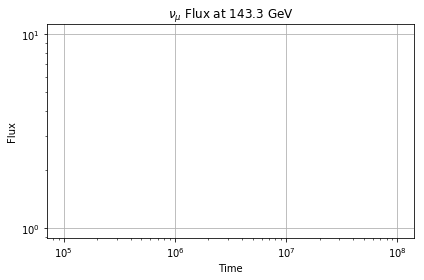

3398210000000000.0
316227.76601683797


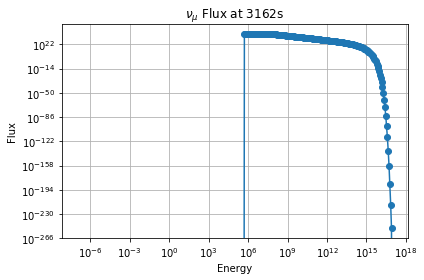

5.02836e+37


In [10]:
import matplotlib.pyplot as plt
        
plt.loglog(times, flux_vals[:, 90], marker='o')
plt.xlabel('Time')
plt.ylabel(r'Flux')
plt.title(r'$\nu_{\mu}$ Flux at 143.3 GeV')
plt.grid(True)
plt.tight_layout()
plt.show()
print(energy_vals[360])
print(times[5])

plt.loglog(energy_vals, flux_vals[5], marker='o')
plt.xlabel('Energy')
plt.ylabel(r'Flux')
plt.title(r'$\nu_{\mu}$ Flux at 3162s')
plt.grid(True)
plt.tight_layout()
plt.show()

print(np.max(flux_vals))

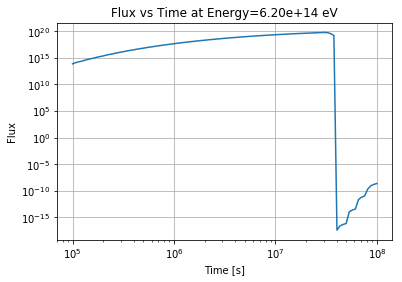

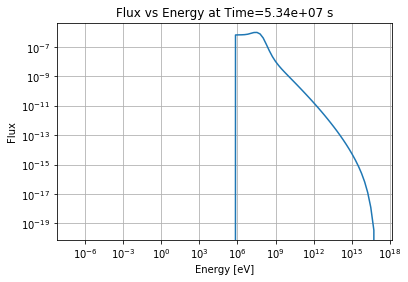

In [12]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

# Make sure flux_vals has the correct shape
flux_vals_2d = np.array(flux_vals).reshape(len(times), len(energy_vals))

# Create the interpolator function:
# Note the order: (times, energy)
flux_interp = RegularGridInterpolator(
    (times, energy_vals),   # grid points as a tuple of arrays
    flux_vals_2d,          # values on the grid
    bounds_error=False,    # don't raise error outside the grid
    fill_value=0           # fill with 0 outside interpolation range
)

times_array = np.logspace(np.log10(times[0]), np.log10(times[-1]), 100)
energies_array = np.logspace(np.log10(energy_vals[0]), np.log10(energy_vals[-1]), 100)

# If you want a grid of points for a 2D map:
t_grid, e_grid = np.meshgrid(times_array, energies_array, indexing='ij')

# Flatten the grid to list of points for the interpolator:
points = np.vstack([t_grid.ravel(), e_grid.ravel()]).T  # shape (N_points, 2)

# Interpolate flux:
flux_interpolated = flux_interp(points)

# Reshape back to 2D (same shape as t_grid and e_grid)
flux_interpolated_2d = flux_interpolated.reshape(t_grid.shape)

# Example plot for fixed energy slice (or fixed time slice):

import matplotlib.pyplot as plt

# Plot flux vs time at fixed energy index 50:
energy_idx = 90
plt.loglog(times_array, flux_interpolated_2d[:, energy_idx])
plt.xlabel("Time [s]")
plt.ylabel("Flux")
plt.title(f"Flux vs Time at Energy={energies_array[energy_idx]:.2e} eV")
plt.grid(True)
plt.show()

# Or flux vs energy at fixed time index 50:
time_idx = 90
plt.loglog(energies_array, flux_interpolated_2d[time_idx, :])
plt.xlabel("Energy [eV]")
plt.ylabel("Flux")
plt.title(f"Flux vs Energy at Time={times_array[time_idx]:.2e} s")
plt.grid(True)
plt.show()

In [13]:
from scipy.integrate import quad

for file, color in zip(filenames, colors):
    if file == "FinalFluxs22_IIn.dat":
        times = [1e5 * 10**(0.1 * k) for k in range(len(block_data))]
    else:
        times = [1e3 * 10**(0.1 * k) for k in range(len(block_data))]
    t_min = min(times)
    t_max = max(times)
    e_min = 1e-1
    e_max = 1e7

def integrand(energy, time):
    return flux_interp(energy, time)

def inner_integral(time):
    result,error = quad(integrand, t_min, t_max, args=(time,))
    return result

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/RHEL_8_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:71: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


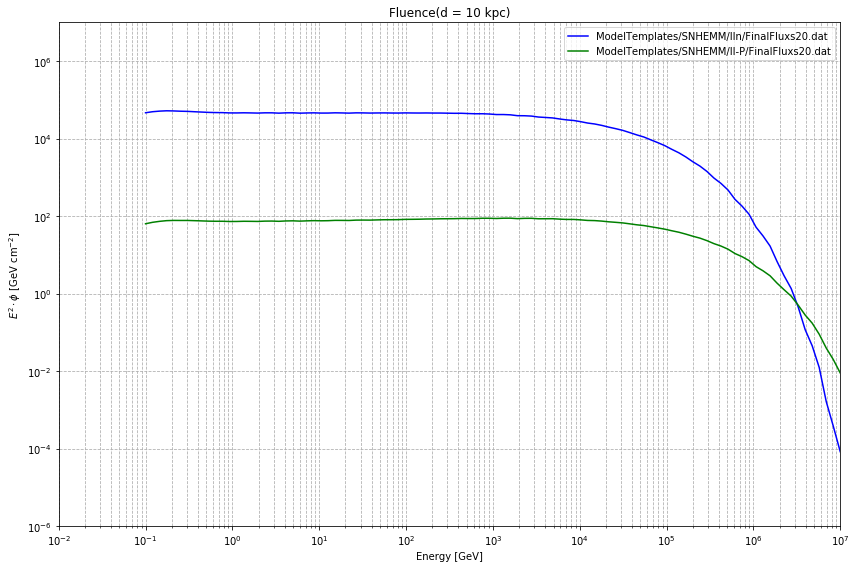

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad, dblquad
from scipy.interpolate import interp2d, RegularGridInterpolator

radius_kpc = 10  # distance to SN
radius_cm = radius_kpc * 3.086e21
sphere_area = 4 * np.pi * radius_cm**2

filenames = ["ModelTemplates/SNHEMM/IIn/FinalFluxs20.dat", "ModelTemplates/SNHEMM/II-P/FinalFluxs20.dat"]
colors = ['blue', 'green']

fig, ax = plt.subplots(figsize=(12, 8))
plt.tight_layout(pad=2.0)

e_min = 1e-1 # GeV
e_max = 1e7 # GeV
energies = np.logspace(np.log10(e_min), np.log10(e_max), 100)

for file, color in zip(filenames, colors):
    block_data = []
    with open(file, "r") as f:
        block = []
        for line in f:
            if line.strip():
                block.append([float(x) for x in line.strip().split()])
            elif block:
                block_data.append(np.array(block))
                block = []
        if block:
            block_data.append(np.array(block))

    if "IIn" in file:
        times = [1e5 * 10**(0.1 * k) for k in range(len(block_data))]
        #t_max = 10**7.5
        #t_min = 10**5.5
    else:
        times = [1e3 * 10**(0.1 * k) for k in range(len(block_data))]
        #t_max = 10**5.8
        #t_min = 1e5
    t_min = min(times)
    t_max = max(times)

    #flux_vals = np.array([[row[7] for row in block] for block in block_data])
    flux_vals = np.array([[row[7]*row[13]* 1e9 for row in block] for block in block_data])
    
    #num_blocks = flux_vals.shape[0]
    energy_vals = np.array([row[0] / 1e9 for row in block_data[0]])
    #energy_vals = np.array([[row[0] / 1e9 for row in block] for block in block_data])
    
    t = np.logspace(t_min, t_max, 1000)
    
    #np.savetxt(f"{file}.txt", flux_vals, fmt="%.6e", delimiter=" ")
    #np.savetxt(f"{file}_energy.txt", energy_vals, fmt="%.6e", delimiter=" ")
    #flux_interp = interp2d(energy_vals, times, flux_vals, kind='cubic', fill_value=0)
    flux_interp = RegularGridInterpolator(
        (times, energy_vals),
        flux_vals,
        method='linear',
        bounds_error=False,
        fill_value=0
    )
    
    fluences = []
    for E in energies:
        try:
            def integrand(log_t):
                t = 10 ** log_t
                return float(flux_interp([[t, E]])) * t * np.log(10)
                #return float(flux_interp(E, t)) * t * np.log(10)
            time_integral, _ = quad(integrand, np.log10(t_min), np.log10(t_max), epsabs=1e-5, epsrel=1e-5)
            fluence = (E**2 * time_integral) / sphere_area
            # fluence /= 1e9  # Convert from eV to GeV
        except Exception:
            fluence = 0
        fluences.append(fluence) # / (4 * np.pi))

    plt.loglog(energies, fluences, label=file, color=color)
    
plt.xlabel("Energy [GeV]")
plt.ylabel(r"$E^2 \cdot \phi$ [GeV cm$^{-2}$]")
plt.title("Fluence(d = 10 kpc)")
plt.xlim(1e-2,1e7)
plt.ylim(1e-6,1e7)
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.savefig("fluence_plot_no_CR.png", dpi=300)

plt.show()

In [22]:
flux_interp = interp2d(np.log10(energy_vals), np.log10(times), flux_vals, kind='cubic', fill_value=0)

result, error = dblquad(flux_interp, np.log10(t_min), np.log10(t_max), lambda x: np.log10(e_min), lambda x: np.log10(e_max), epsabs=1e-5, epsrel=1e-5)

In [23]:
print(result, len(times))

6.343479753242254e+34 51


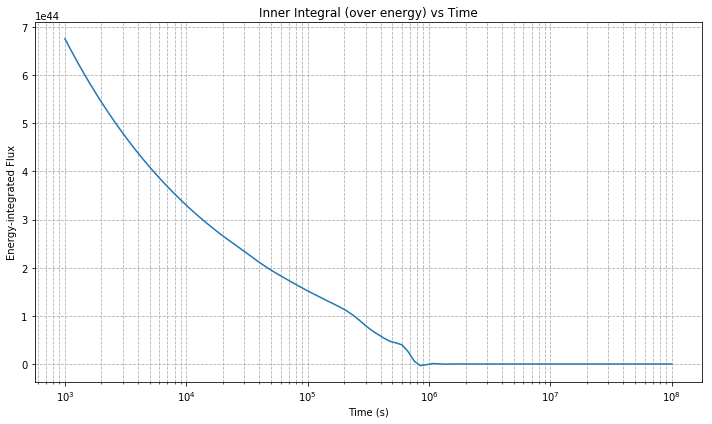

In [14]:
flux_interp = interp2d(np.log10(energy_vals), np.log10(times), flux_vals, kind='cubic', fill_value=0)

# Define time values to evaluate (in linear scale)
t_vals = np.logspace(np.log10(min(times)), np.log10(max(times)), 100)
inner_integrals = []

for t in t_vals:
    logT = np.log10(t)

    def integrand(logE):
        E = 10**logE
        return float(flux_interp(logE, logT)) * E * np.log(10)

    result, _ = quad(integrand, np.log10(min(energy_vals)), np.log10(max(energy_vals)), epsabs=1e-5, epsrel=1e-5)
    inner_integrals.append(result)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t_vals, inner_integrals)
plt.xscale("log")
plt.xlabel("Time (s)")
plt.ylabel("Energy-integrated Flux")
plt.title("Inner Integral (over energy) vs Time")
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

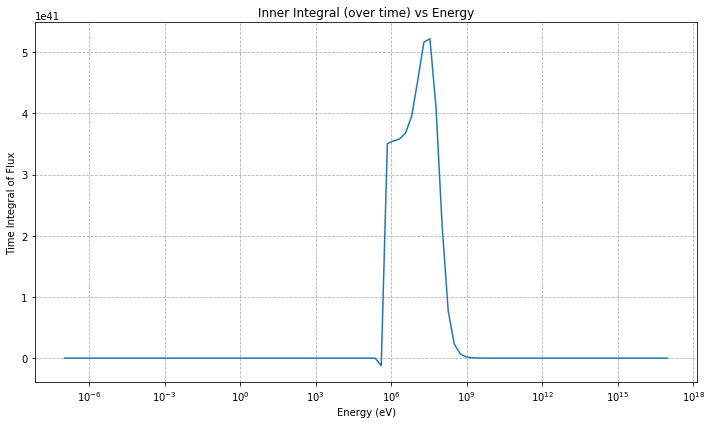

In [15]:
logE_vals = np.linspace(np.log10(min(energy_vals)), np.log10(max(energy_vals)), 100)

inner_integrals = []

for logE in logE_vals:
    def integrand(logT):
        T = 10**logT
        return float(flux_interp(logE, logT)) * T * np.log(10)

    inner_result, _ = quad(integrand, np.log10(min(times)), np.log10(max(times)), epsabs=1e-5, epsrel=1e-5)
    inner_integrals.append(inner_result)

# Convert log-energy back to linear for plotting
E_vals = 10**logE_vals

# Plot
plt.figure(figsize=(10, 6))
plt.plot(E_vals, inner_integrals)
plt.xscale("log")
plt.xlabel("Energy (eV)")
plt.ylabel("Time Integral of Flux")
plt.title("Inner Integral (over time) vs Energy")
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

In [16]:
from scipy.interpolate import RegularGridInterpolator

log_energy_vals = np.log10(energy_vals)
log_times = np.log10(times)

flux_interp = RegularGridInterpolator((log_times, log_energy_vals), flux_vals, method='linear', bounds_error=False, fill_value=0)

In [21]:
def integrand(log_t, log_e):
    val = flux_interp([[log_t, log_e]])[0]  # Must pass as a 2D array
    return val

result, error = dblquad(
    integrand,
    np.log10(t_min), np.log10(t_max),
    lambda x: np.log10(e_min / 1e9), lambda x: np.log10(e_max / 1e9),
    epsabs=1e-5,
    epsrel=1e-5
)
print(result)

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/RHEL_8_x86_64/lib/python3.7/site-packages/scipy/integrate/quadpack.py:860: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  **opt)


5.0157688431351775e+35


In [20]:
print("log10(t_min), log10(t_max):", np.log10(t_min), np.log10(t_max))
print("log10(e_min), log10(e_max):", np.log10(e_min), np.log10(e_max))
print("interp grid ranges:", np.log10(times)[[0, -1]], np.log10(energy_vals)[[0, -1]])

log10(t_min), log10(t_max): 5.0 5.8
log10(e_min), log10(e_max): 8.0 16.0
interp grid ranges: [3. 8.] [-6.96874912 16.96874998]


In [ ]:
    
    time_energy_tuples = []
    for time in times:
        for energy in energy_vals:
            tuple_val = [time, energy]
            time_energy_tuples.append(tuple_val)
            
    flux_interp = RegularGridInterpolator(
        (np.log10(times), np.log10(energy_vals)),   # grid points as a tuple of arrays
        weighted_vals,          # values on the grid
        method='linear',
        bounds_error=False,    # don't raise error outside the grid
        fill_value=0           # fill with 0 outside interpolation range
    )

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/RHEL_8_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:43: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.


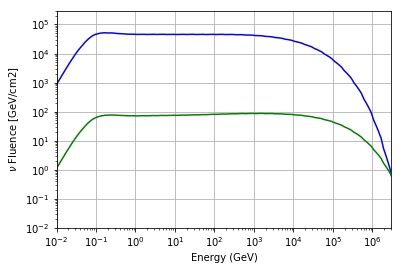

In [50]:
import pandas as pd
import numpy as np
import scipy as sp

radius_kpc = 10  # distance to SN
radius_cm = radius_kpc * 3.086e21
sphere_area = 4 * np.pi * radius_cm**2



filenames = ["ModelTemplates/SNHEMM/IIn/FinalFluxs20.dat", "ModelTemplates/SNHEMM/II-P/FinalFluxs20.dat"]
colors = ['blue', 'green']

for file, color in zip(filenames, colors):
    df = pd.read_csv(file, header=None, sep=' ')
    
    num_blocks = int(df.shape[0] / 384 )
    
    if "IIn" in file:
        df['times'] = 1e5 * 10**(0.1 * np.repeat(np.arange(num_blocks), 384))
    else:
        df['times'] = 1e3 * 10**(0.1 * np.repeat(np.arange(num_blocks), 384))
        
    energies = np.asarray(df[0]).reshape((num_blocks, 384)) / 1e9
    lumi_vals = np.asarray(df[7] * df[13] * df[0] * df[0]).reshape((num_blocks, 384)) / 1e9
    time_arr = np.asarray(df['times']).reshape((num_blocks, 384))

    times = time_arr[:,0]
    
    def get_dLumi_neutrino_dE_atEnergy(time, energy_index, times): 
        
        dLumidE = lumi_vals[:,energy_index]
        
        return np.interp(time, times, dLumidE)
    
    def get_timeIntegrated_dLumi_neutrino_dE(times):
        
        timeIntegrated_dLumi_neutrino_dE = np.zeros(384)
        
        for energy_index in range(384):
            integrand = lambda t: get_dLumi_neutrino_dE_atEnergy(t, energy_index, times)
            timeIntegrated_dLumi_neutrino_dE[energy_index] = sp.integrate.quad(
                integrand, times[0], times[-1], limit=10000
            )[0]
    
        return timeIntegrated_dLumi_neutrino_dE
    
    plt.plot(energies[0], get_timeIntegrated_dLumi_neutrino_dE(times) / sphere_area, color=color)

plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-2, 3e6)
plt.ylim(1e-2, 3e5)
#plt.legend(loc='lower left')
plt.xlabel('Energy (GeV)')
#plt.ylabel(r'$\nu_\mu$ Flux (GeV/cm2)')
plt.ylabel(r'$\nu$ Fluence [GeV/cm2]')

plt.grid()


In [ ]:
def get_dLumi_neutrino_dE_atEnergy(times, t, energy_index, lumi_vals): 
        dLumi_dE = lumi_vals[:, energy_index]
        
        return np.interp(t, times, dLumi_dE)

    def get_timeIntegrated_dLumi_neutrino_dE(times, t, t_min, t_max, lumi_vals):
        
        timeIntegrated_dLumi_neutrino_dE = np.zeros(384)
        
        for energy_index in range(384):
            timeIntegrated_dLumi_neutrino_dE[energy_index] = quad(
            lambda t: get_dLumi_neutrino_dE_atEnergy(times, t, energy_index, lumi_vals),
            t_min,
            t_max,
            limit=10000
        )[0]
    
        return timeIntegrated_dLumi_neutrino_dE
    plt.loglog(np.unique(energy_vals), get_timeIntegrated_dLumi_neutrino_dE(times, t, t_min, t_max, lumi_vals) / sphere_area, color=color)

    
    
    
    
# prev code for detector_calc.py

for file, energy in zip(filenames, energies):
    flx = np.loadtxt(file)
    e = np.loadtxt(energy)
    
    e_min = 100 # in GeV
    e_max = 10**6 # in GeV
    #e_min = min(e) / 1e9 # convert to GeV
    #e_max = max(e) / 1e9 # convert to GeV
    
    if file == "FinalFluxs22_IIn.txt":
        times = [1e5 * 10**(0.1 * k) for k in range(len(flx))]
        t_max = 10**7.5
    else:
        times = [1e3 * 10**(0.1 * k) for k in range(len(flx))]
        t_max = 10**5.8

    t_min = min(times)
    t_max = 100*24*3600 #max(times)
    
    print(f"min time: {t_min}, max time: {t_max}")
    print(len(flx))
    
    flux_interp = interp2d(np.log10(e / 1e9), np.log10(times), flx * 1e9, kind='cubic', fill_value=0) # convert to GeV
    
    # integrand functions
    def integrand(log_t, log_e):
        E = 10**log_e
        T = 10**log_t
        return (float(xs_interp(log_e)) *
                float(flux_interp(log_e, log_t)) *
                np.log(10)**2 * T * E)

    def inner_integral(log_e):
        result,error = quad(integrand, np.log10(t_min), np.log10(t_max), args=(log_e,))
        return result
    
    result, error = quad(inner_integral, np.log10(e_min), np.log10(e_max)) 
    
    result *= (N_det / sphere_area)
    
    print(f"{file}: {result}")
